In [2]:
# Cell 0 — Setup: install and imports
# Install missing libs (quiet mode)
!pip install -q plotnine mplcursors

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplcursors
from plotnine import ggplot, aes, geom_point, geom_line, geom_ribbon, facet_wrap, theme_minimal, labs, scale_color_brewer
from plotnine.data import mpg, economics


In [3]:
# Cell 1 — Data (Iris) with two continuous variables
from sklearn.datasets import load_iris

iris_bunch = load_iris(as_frame=True)
iris = iris_bunch.frame.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width"
})
iris['species'] = iris_bunch.target_names[iris_bunch.target]
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
# Cell 2 — Multi-layered figure: plotnine scatter + marginal histograms (fixed)
xcol, ycol = "sepal_length", "sepal_width"

# Plotnine scatter (returns a Matplotlib Figure when drawn)
base = (
    ggplot(iris, aes(x=xcol, y=ycol, color='species')) +
    geom_point(alpha=0.7, size=2) +
    theme_minimal() +
    labs(
        title="Iris — Scatter with Marginal Histograms",
        x="Sepal Length (cm)",
        y="Sepal Width (cm)",
        color="Species"
    ) +
    scale_color_brewer(type="qual", palette=2)
)

# Draw the plotnine graphic to get the underlying Matplotlib Figure/Axes
fig = base.draw()             # <-- no 'ax=' argument; this returns a Figure
ax_scatter = fig.axes[0]      # plotnine's main axes

# Compute positions to add marginal axes within the same figure
bbox = ax_scatter.get_position()  # Bbox in figure coordinates
hist_frac = 0.18                  # fraction of the scatter height/width for histograms
pad = 0.01                        # small padding

# Top histogram (shares x with scatter)
ax_histx = fig.add_axes([
    bbox.x0,
    bbox.y1 + pad,
    bbox.width,
    hist_frac * bbox.height
])
# Right histogram (shares y with scatter)
ax_histy = fig.add_axes([
    bbox.x1 + pad,
    bbox.y0,
    hist_frac * bbox.width,
    bbox.height
])

# Match limits
xlim = ax_scatter.get_xlim()
ylim = ax_scatter.get_ylim()

# Plot histograms per species
for name, grp in iris.groupby('species'):
    ax_histx.hist(grp[xcol], bins=20, alpha=0.4, label=name)
    ax_histy.hist(grp[ycol], bins=20, alpha=0.4, orientation='horizontal', label=name)

# Style marginal axes
ax_histx.set_xlim(xlim)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.tick_params(axis="y", left=False, labelleft=False)
ax_histx.set_ylabel("")

ax_histy.set_ylim(ylim)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.tick_params(axis="x", bottom=False, labelbottom=False)
ax_histy.set_xlabel("")

# Put legend only once (top hist)
handles, labels = ax_histx.get_legend_handles_labels()
if handles:
    ax_histx.legend(handles, labels, loc="upper right", title="Species")

# Make sure titles/labels remain visible
ax_scatter.set_title("Iris — Scatter with Marginal Histograms")

plt.show()


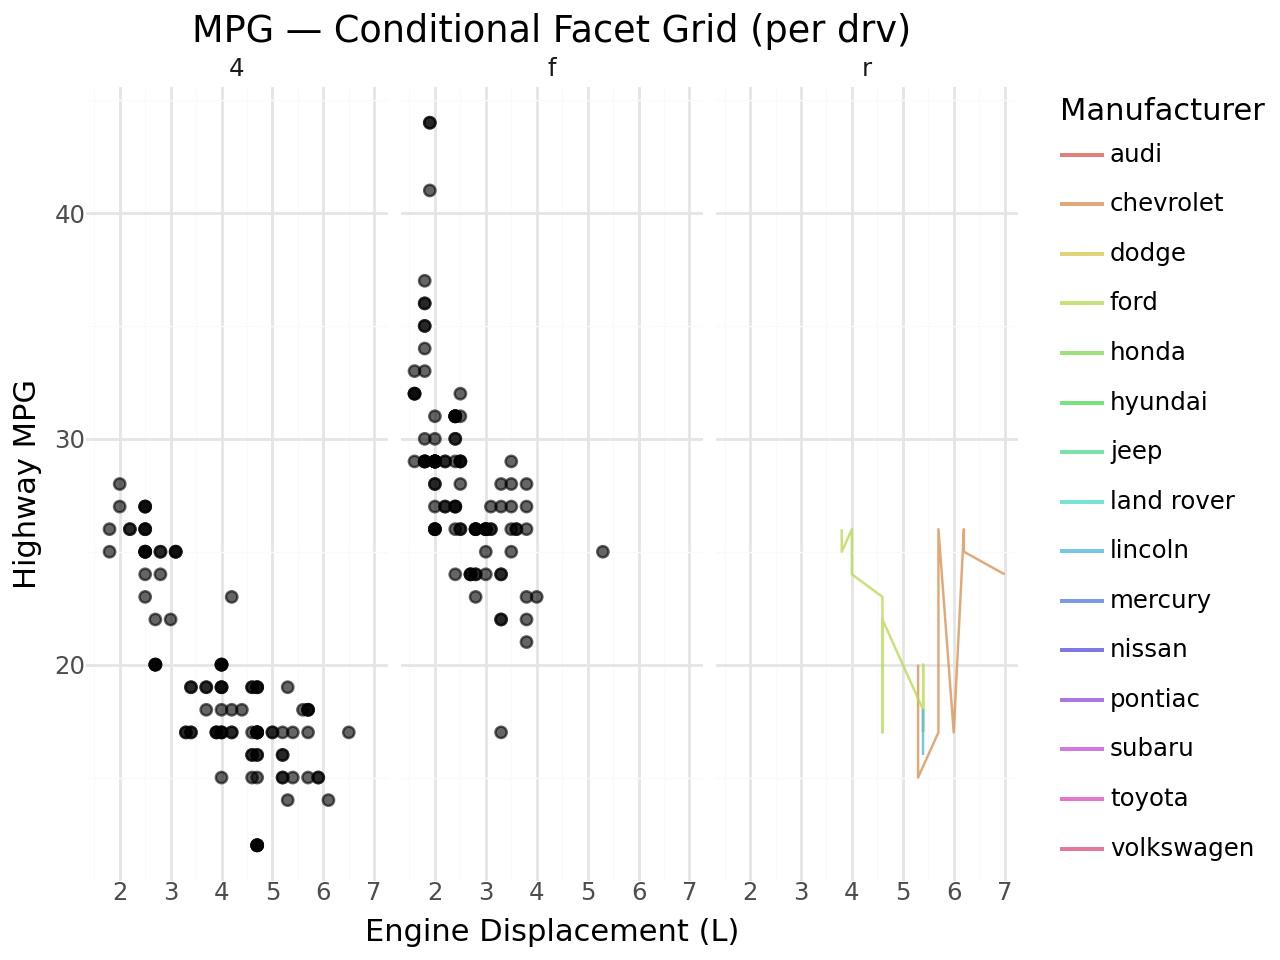

In [7]:
# Cell 3 — Facet grid with conditional geoms (drv) — FIXED
from plotnine import ggplot, aes, geom_point, geom_line, facet_wrap, theme_minimal, labs
import warnings
warnings.filterwarnings("ignore", message="The default of observed=False is deprecated")

df = mpg.copy()

# Decide geometry per facet value
geom_for = {'f': 'scatter', '4': 'scatter', 'r': 'line'}

# Start ggplot base
facet_plot = ggplot(df, aes(x='displ', y='hwy'))

# Add layers per group
for drv_key, part in df.groupby('drv', observed=False):
    if geom_for.get(drv_key) == 'scatter':
        facet_plot = facet_plot + geom_point(data=part, mapping=aes('displ', 'hwy'),
                                             alpha=0.6, size=1.8)
    else:
        part2 = part.sort_values('displ')
        facet_plot = facet_plot + geom_line(data=part2,
                                            mapping=aes('displ', 'hwy', color='manufacturer'),
                                            alpha=0.8)

# Finish plot with facets and labels
facet_plot = (
    facet_plot
    + facet_wrap('~drv', nrow=1)
    + theme_minimal()
    + labs(
        title="MPG — Conditional Facet Grid (per drv)",
        x="Engine Displacement (L)",
        y="Highway MPG",
        color="Manufacturer"
    )
)

facet_plot


In [8]:
# Cell 4 — Time series prep: rolling average and 95% CI
ts = economics.copy()[['date', 'unemploy']].sort_values('date')

window = 12  # months
ts['roll_mean'] = ts['unemploy'].rolling(window=window, min_periods=window).mean()
ts['roll_std']  = ts['unemploy'].rolling(window=window, min_periods=window).std()

n = window
ts['ci_low']  = ts['roll_mean'] - 1.96 * (ts['roll_std'] / np.sqrt(n))
ts['ci_high'] = ts['roll_mean'] + 1.96 * (ts['roll_std'] / np.sqrt(n))

ts.tail(10)


,date,unemploy,roll_mean,roll_std,ci_low,ci_high
564,2014-07-01,9648,10371.000000,643.397092,10006.963825,10735.036175
565,2014-08-01,9568,10231.583333,618.518973,9881.623280,10581.543387
566,2014-09-01,9237,10063.750000,589.313333,9730.314593,10397.185407
567,2014-10-01,8983,9882.250000,555.055136,9568.197992,10196.302008
568,2014-11-01,9071,9737.000000,515.729492,9445.198570,10028.801430
569,2014-12-01,8688,9596.333333,554.353076,9282.678553,9909.988113
570,2015-01-01,8979,9487.916667,535.386939,9184.992989,9790.840344
571,2015-02-01,8705,9347.750000,497.436908,9066.298574,9629.201426
572,2015-03-01,8575,9197.000000,423.459776,8957.405077,9436.594923
573,2015-04-01,8549,9101.416667,429.986143,8858.129103,9344.704230


/usr/local/lib/python3.12/dist-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 11 rows containing missing values.


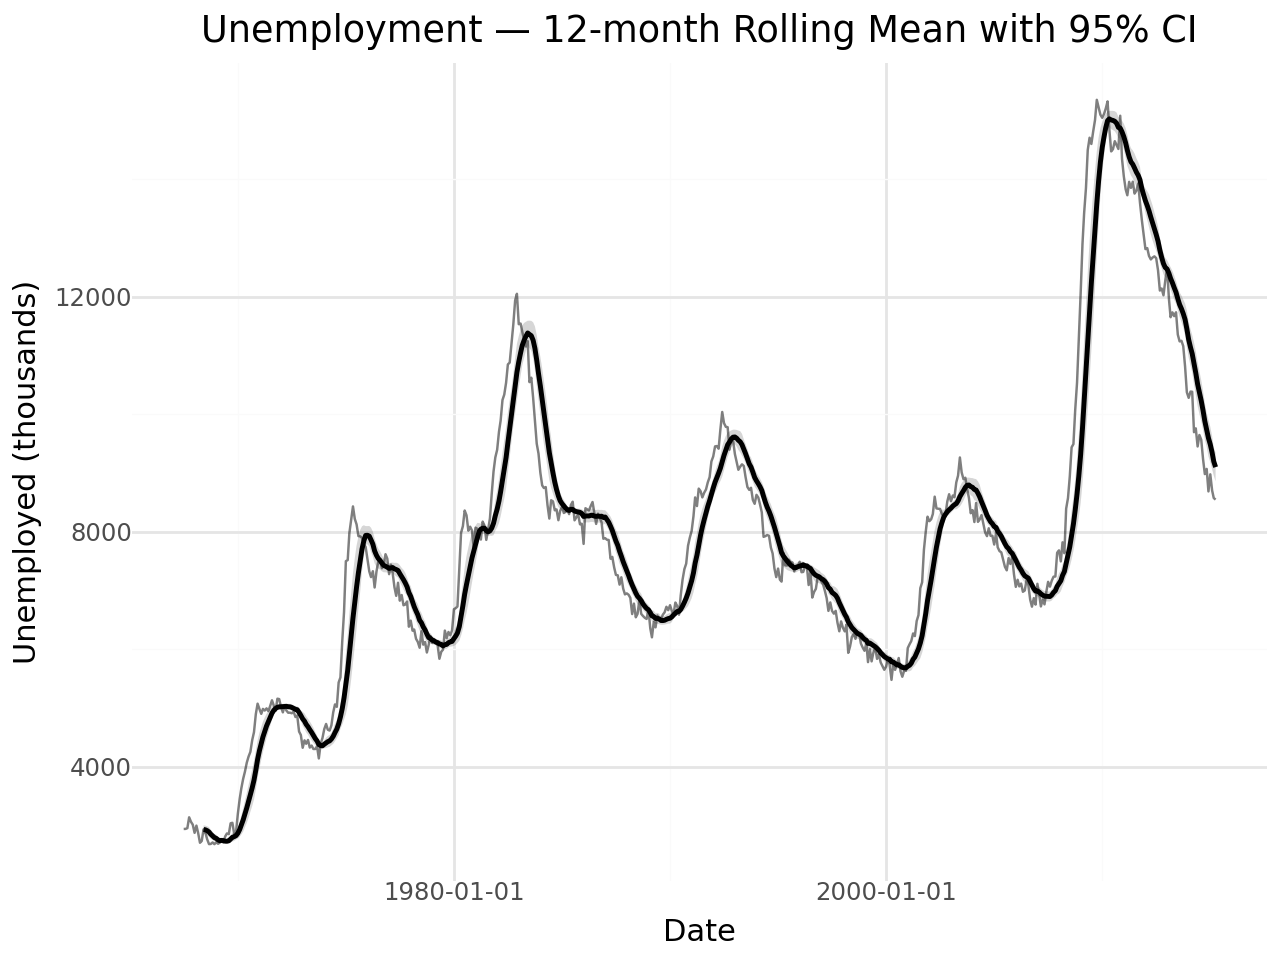

In [9]:
# Cell 5 — Time series with rolling mean and CI ribbon (plotnine)
from plotnine import geom_ribbon

p_ts = (
    ggplot(ts, aes('date', 'unemploy'))
    + geom_line(alpha=0.5)
    + geom_ribbon(aes(ymin='ci_low', ymax='ci_high'), alpha=0.2)
    + geom_line(aes(y='roll_mean'), size=1.0)
    + theme_minimal()
    + labs(
        title=f"Unemployment — {window}-month Rolling Mean with 95% CI",
        x="Date",
        y="Unemployed (thousands)"
    )
)
p_ts
